# U-Nesting Playground

Explore the `Board2D` API interactively: load parts, nest them, visualise results, and try the RL-style incremental placement interface.

In [1]:
import sys, json, math, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon

# Make sure the venv's u_nesting is on the path
sys.path.insert(0, str(Path("crates/python/python").resolve()))

import u_nesting

print("u_nesting version:", u_nesting.version())
print("Available strategies:", u_nesting.available_strategies())

u_nesting version: 0.3.1
Available strategies: ['blf', 'nfp', 'ga', 'brkga', 'sa', 'ep']


## 1. Load the dataset

In [2]:
DATASET = Path("data/aligner_svgs.json")

with open(DATASET) as f:
    data = json.load(f)

print(f"Dataset: {data['name']}")
print(f"Number of part types: {len(data['items'])}")

# Quick size overview
areas = []
for item in data['items']:
    verts = item['shape']['data']
    n = len(verts)
    area = abs(sum(verts[i][0]*verts[(i+1)%n][1] - verts[(i+1)%n][0]*verts[i][1]
                   for i in range(n))) / 2
    areas.append(area)

print(f"\nPart area — min: {min(areas):.1f}  max: {max(areas):.1f}  mean: {sum(areas)/len(areas):.1f} mm²")

Dataset: aligner_svgs
Number of part types: 72

Part area — min: 1113.0  max: 1690.3  mean: 1265.5 mm²


## 2. Sample parts & create the board

In [3]:
# ── Parameters ────────────────────────────────────────────────────────────────
N_PARTS    = 20              # how many parts to sample (library has 72)
SEED       = 42              # random seed (None = random)
BOARD_W    = 280.0           # mm — fits ~20 aligner parts comfortably
BOARD_H    = 200.0
STRATEGY   = "nfp"           # "nfp" | "blf"
ROTATIONS  = [0, 45, 90, 135, 180, 225, 270, 315]   # degrees
# ──────────────────────────────────────────────────────────────────────────────

rng = random.Random(SEED)
sampled = rng.sample(data["items"], N_PARTS)

parts = [
    {
        "id": item["label"],
        "polygon": item["shape"]["data"],
        "rotations": ROTATIONS if ROTATIONS is not None else item["allowed_orientations"],
    }
    for item in sampled
]

BOUNDARY = {"width": BOARD_W, "height": BOARD_H}
CONFIG   = {"strategy": STRATEGY, "spacing": 0.0}

board = u_nesting.Board2D(boundary=BOUNDARY, geometries=parts, config=CONFIG)
print(f"Board created — {len(parts)} parts loaded")
print(f"Plate: {BOARD_W:.0f}×{BOARD_H:.0f} mm   Rotations: {ROTATIONS}")

Board created — 20 parts loaded
Plate: 280×200 mm   Rotations: [0, 45, 90, 135, 180, 225, 270, 315]


## 3. Interactive step-by-step placement

In [4]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── State ─────────────────────────────────────────────────────────────────────
board.reset()
_step = {"i": 0}
cmap  = plt.get_cmap("tab20")

# ── Render helpers ─────────────────────────────────────────────────────────────
def _draw_board(ax):
    ax.add_patch(plt.Rectangle((0, 0), BOARD_W, BOARD_H,
                                linewidth=2, edgecolor="black", facecolor="#f5f5f5"))
    for j, (verts, pl) in enumerate(zip(board.placed_polygons(), board.placements())):
        color = cmap(j % 20)
        ax.add_patch(MplPolygon(verts, closed=True,
                                facecolor=(*color[:3], 0.6),
                                edgecolor="black", linewidth=0.8))
    ax.set_xlim(-2, BOARD_W + 2); ax.set_ylim(-2, BOARD_H + 2)
    ax.set_aspect("equal"); ax.axis("off")

out = widgets.Output()

def refresh():
    i = _step["i"]
    with out:
        clear_output(wait=True)

        fig, axes = plt.subplots(1, 3, figsize=(14, 5),
                                 gridspec_kw={"width_ratios": [2, 1, 1]})

        # Left: board
        _draw_board(axes[0])
        n_placed = board.placed_count()
        util     = board.utilization()
        next_id  = parts[i]["id"] if i < len(parts) else "—"
        axes[0].set_title(
            f"Step {i}/{len(parts)}  |  placed: {n_placed}  |  util: {util:.1%}\n"
            f"Next: {next_id}",
            fontsize=10
        )

        # Middle: last placed part at its ACTUAL rotation
        placed = board.placements()
        if placed:
            last     = placed[-1]
            rot_deg  = round(math.degrees(last["rotation"]), 1)
            img      = board.render_placement(last)
            axes[1].imshow(img, cmap="gray", vmin=0, vmax=1, origin="lower")
            axes[1].set_title(f"Last placed: {last['geometry_id']}\nat {rot_deg}°  ← actual rotation", fontsize=9)
        else:
            axes[1].text(0.5, 0.5, "nothing placed yet", ha="center", va="center",
                         transform=axes[1].transAxes, fontsize=10, color="gray")
            axes[1].set_title("Last placed", fontsize=9)
        axes[1].axis("off")

        # Right: next part native shape (0° — for reference only)
        if i < len(parts):
            canvas = board.part_canvas(parts[i]["id"])
            axes[2].imshow(canvas, cmap="gray", vmin=0, vmax=1, origin="lower")
            axes[2].set_title(
                f"Next: {parts[i]['id']}\n(native 0° shape — engine picks best rotation)",
                fontsize=9
            )
        else:
            axes[2].text(0.5, 0.5, "All parts processed", ha="center", va="center",
                         transform=axes[2].transAxes, fontsize=12)
            axes[2].set_title("Done", fontsize=9)
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()

def on_place(_):
    i = _step["i"]
    if i >= len(parts):
        return
    board.place(parts[i]["id"])
    _step["i"] += 1
    refresh()

def on_undo(_):
    if board.placed_count() == 0:
        return
    board.undo()
    _step["i"] = max(0, _step["i"] - 1)
    refresh()

def on_reset(_):
    board.reset()
    _step["i"] = 0
    refresh()

btn_place = widgets.Button(description="Place next", button_style="success",
                           layout=widgets.Layout(width="140px"))
btn_undo  = widgets.Button(description="Undo",       button_style="warning",
                           layout=widgets.Layout(width="100px"))
btn_reset = widgets.Button(description="Reset",      button_style="danger",
                           layout=widgets.Layout(width="100px"))

btn_place.on_click(on_place)
btn_undo.on_click(on_undo)
btn_reset.on_click(on_reset)

display(widgets.HBox([btn_place, btn_undo, btn_reset]), out)
refresh()

Output()

## 4. Visualise the nest

In [ ]:
def plot_board(board, boundary, title=None):
    w, h = boundary["width"], boundary["height"]
    cmap = plt.get_cmap("tab20")
    placed = board.placements()

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.add_patch(plt.Rectangle((0, 0), w, h, linewidth=2,
                                edgecolor="black", facecolor="#f5f5f5"))

    color_map = {p["geometry_id"]: cmap(i % 20)
                 for i, p in enumerate(placed)}

    for poly_verts, placement in zip(board.placed_polygons(), placed):
        color = color_map[placement["geometry_id"]]
        patch = MplPolygon(poly_verts, closed=True,
                           facecolor=(*color[:3], 0.6),
                           edgecolor="black", linewidth=0.8)
        ax.add_patch(patch)

    n_placed = board.placed_count()
    util = board.utilization()
    ax.set_title(title or f"{n_placed} placed — {util:.1%} utilization", fontsize=11)
    ax.set_xlim(-2, w + 2)
    ax.set_ylim(-2, h + 2)
    ax.set_aspect("equal")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    plt.tight_layout()
    plt.show()

plot_board(board, BOUNDARY)

## 5. SDF images — board & individual placements

In [ ]:
# Full board SDF
board_img = board.board_image()   # (1, 128, 128) float32

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(board_img[0], cmap="gray", vmin=0, vmax=1, origin="lower")
ax.set_title("Board SDF (0=occupied, 1=empty)")
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# First 8 individual placement SDFs (rotation clearly visible — centered canvas)
placements = board.placements()
n_show = min(8, len(placements))
fig, axes = plt.subplots(1, n_show, figsize=(2 * n_show, 2.5))
if n_show == 1:
    axes = [axes]
for ax, placement in zip(axes, placements[:n_show]):
    img = board.render_placement(placement)
    rot_deg = round(math.degrees(placement["rotation"]), 1)
    ax.imshow(img, cmap="gray", vmin=0, vmax=1, origin="lower")
    ax.set_title(f"{placement['geometry_id']}\n{rot_deg}°", fontsize=7)
    ax.axis("off")
plt.suptitle("Individual placement SDFs (rotated)", fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# Per-part canvases (centered, no board context) — RL static features
n_show = min(8, len(parts))
fig, axes = plt.subplots(1, n_show, figsize=(2 * n_show, 2.5))
for ax, p in zip(axes, parts[:n_show]):
    canvas = board.part_canvas(p["id"])
    ax.imshow(canvas, cmap="gray", vmin=0, vmax=1, origin="lower")
    ax.set_title(p["id"], fontsize=7)
    ax.axis("off")
plt.suptitle("Part canvases (static per-episode features)", fontsize=10)
plt.tight_layout()
plt.show()

## 7. Snapshot / restore — RL rollout pattern

In [ ]:
# Place the first 3 parts, then branch
board.reset()
for p in parts[:3]:
    board.place(p["id"])

print(f"After 3 parts: {board.placed_count()} placed, {board.utilization():.1%} utilization")

snap = board.snapshot()
print(f"Snapshot saved ({len(snap)} entries)")

# Branch A: place part 4
board.place(parts[3]["id"])
print(f"\nBranch A (+{parts[3]['id']}): {board.placed_count()} placed, {board.utilization():.1%}")
plot_board(board, BOUNDARY, title=f"Branch A: +{parts[3]['id']}")

# Restore and try branch B
board.restore(snap)
print(f"Restored: {board.placed_count()} placed")
board.place(parts[4]["id"])
print(f"Branch B (+{parts[4]['id']}): {board.placed_count()} placed, {board.utilization():.1%}")
plot_board(board, BOUNDARY, title=f"Branch B: +{parts[4]['id']}")

## 8. Compare placement orderings

In [ ]:
def polygon_area(verts):
    n = len(verts)
    return abs(sum(verts[i][0]*verts[(i+1)%n][1] - verts[(i+1)%n][0]*verts[i][1]
                   for i in range(n))) / 2

def run_ordering(board, ordering, label):
    board.reset()
    placed = sum(1 for p in ordering if board.place(p["id"]) is not None)
    util = board.utilization()
    print(f"{label:20s}  placed={placed}/{len(ordering)}  util={util:.1%}")
    return util

# Three orderings to compare
as_sampled  = parts
largest_first  = sorted(parts, key=lambda p: polygon_area(p["polygon"]), reverse=True)
smallest_first = sorted(parts, key=lambda p: polygon_area(p["polygon"]))
shuffled    = parts[:]
random.Random(99).shuffle(shuffled)

run_ordering(board, as_sampled,     "as sampled")
run_ordering(board, largest_first,  "largest first")
run_ordering(board, smallest_first, "smallest first")
run_ordering(board, shuffled,       "shuffled")

# Leave board in largest-first state for subsequent cells
run_ordering(board, largest_first, "largest first (final)")
plot_board(board, BOUNDARY, title="Largest-first ordering")

## 9. Board SDF animation — watch it fill up

In [5]:
board.reset()
snapshots = [board.board_image()[0].copy()]  # empty board

for p in largest_first:
    r = board.place(p["id"])
    if r:
        snapshots.append(board.board_image()[0].copy())

n_snaps = len(snapshots)
n_cols  = min(8, n_snaps)
n_rows  = math.ceil(n_snaps / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 2.2 * n_rows))
axes = axes.flatten()

for i, (img, ax) in enumerate(zip(snapshots, axes)):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1, origin="lower")
    ax.set_title(f"step {i}", fontsize=7)
    ax.axis("off")

for ax in axes[n_snaps:]:
    ax.axis("off")

plt.suptitle("Board SDF after each placement", fontsize=11)
plt.tight_layout()
plt.show()

NameError: name 'largest_first' is not defined

## 10. RL Gym — rotation prediction observation

The training agent operates through `UNestingGymEnv`, which extends the `Board2D`
API with SDF-based observations and the new hierarchical (part, rotation) action space.

In [6]:
import sys
sys.path.insert(0, str(Path("scripts").resolve()))
from u_nesting_gym import UNestingGymEnv

N_ROTATIONS = 8   # agent chooses from 8 evenly-spaced angles

env = UNestingGymEnv(
    "data/aligner_svgs.json",
    plate_width=280.0,
    plate_height=200.0,
    rotations=[0, 45, 90, 135, 180, 225, 270, 315],  # degrees — override for all parts
)

lib_ids = env.sample_episode_ids(n=15, rng=random.Random(42))
env.reset(lib_ids)
print(f"Episode: {len(lib_ids)} parts")

rotations_rad = env.get_rotation_angles(N_ROTATIONS)
print(f"Rotation angles (deg): {[round(math.degrees(r)) for r in rotations_rad]}")

Episode: 15 parts
Rotation angles (deg): [0, 45, 90, 135, 180, 225, 270, 315]


Observation shape: (15, 9, 128, 128)  →  15 parts × 8 rotations + 1 board channel


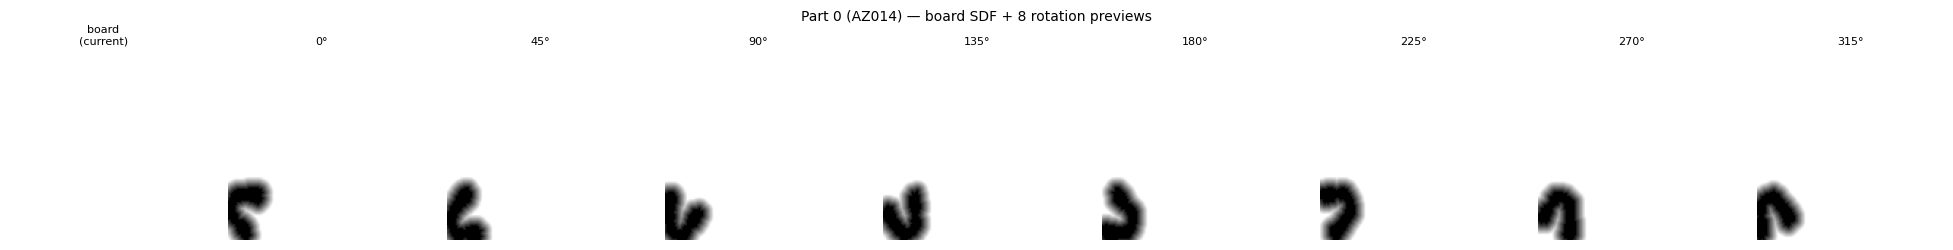

In [7]:
# Build (N, R+1, 128, 128) observation for the current step
obs = env.preview_images_per_rotation(rotations_rad)
N, Rp1, H, W = obs.shape
R = Rp1 - 1
print(f"Observation shape: {obs.shape}  →  {N} parts × {R} rotations + 1 board channel")

# Show one part's full observation: board + all 8 rotation previews
PART_TO_SHOW = 0
fig, axes = plt.subplots(1, R + 1, figsize=(2.2 * (R + 1), 2.5))

axes[0].imshow(obs[PART_TO_SHOW, 0], cmap="gray", vmin=0, vmax=1, origin="lower")
axes[0].set_title("board\n(current)", fontsize=8)
axes[0].axis("off")

for r in range(R):
    axes[r + 1].imshow(obs[PART_TO_SHOW, r + 1], cmap="gray", vmin=0, vmax=1, origin="lower")
    deg = round(math.degrees(rotations_rad[r]))
    axes[r + 1].set_title(f"{deg}°", fontsize=8)
    axes[r + 1].axis("off")

remaining = env.remaining_item_ids()
geom_id = env._episode_geoms()[PART_TO_SHOW]["id"]
placed_str = "" if PART_TO_SHOW in remaining else " (placed)"
plt.suptitle(f"Part {PART_TO_SHOW} ({geom_id}){placed_str} — board SDF + 8 rotation previews", fontsize=10)
plt.tight_layout()
plt.show()

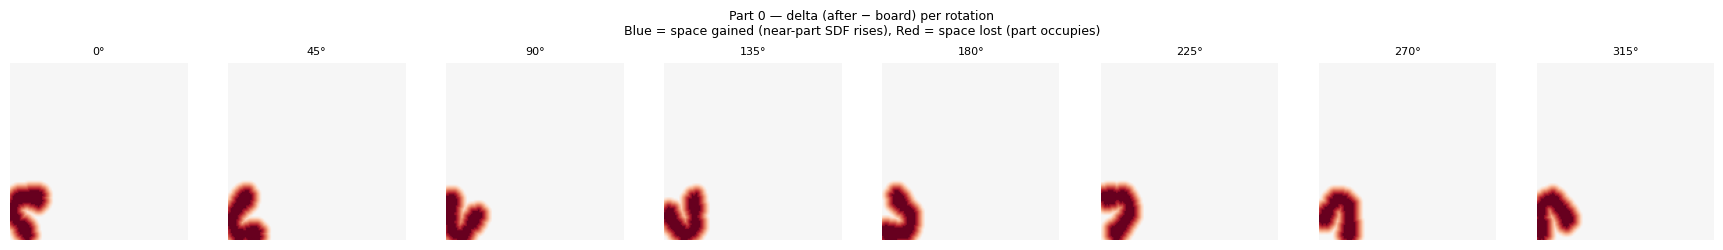

In [8]:
# Delta images: what each rotation *adds* to the board (after - current)
# Bright = the part lands there; dark = part occludes empty space
fig, axes = plt.subplots(1, R, figsize=(2.2 * R, 2.5))

for r in range(R):
    delta = obs[PART_TO_SHOW, r + 1] - obs[PART_TO_SHOW, 0]
    axes[r].imshow(delta, cmap="RdBu", vmin=-1, vmax=1, origin="lower")
    deg = round(math.degrees(rotations_rad[r]))
    axes[r].set_title(f"{deg}°", fontsize=8)
    axes[r].axis("off")

plt.suptitle(f"Part {PART_TO_SHOW} — delta (after − board) per rotation\n"
             "Blue = space gained (near-part SDF rises), Red = space lost (part occupies)", fontsize=9)
plt.tight_layout()
plt.show()

Step  Part       Rotation   Placed   Density
──────────────────────────────────────────────────
  1   AZ017       90°   ✓        0.390
  2   AZ011        0°   ✓        0.402
  3   AZ003       45°   ✓        0.377
  4   AZ054        0°   ✓        0.296
  5   AZ065      135°   ✓        0.322
  6   AZ014       45°   ✓        0.358


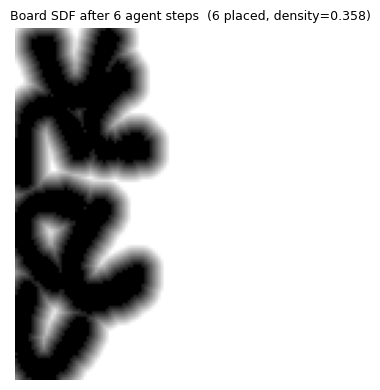

In [9]:
# Simulate a few agent steps with random (part, rotation) choices
# to show the full episode loop

env.reset(lib_ids)
remaining = env.remaining_item_ids()
rng_action = random.Random(7)

print("Step  Part       Rotation   Placed   Density")
print("─" * 50)
for step in range(6):
    remaining = env.remaining_item_ids()
    if not remaining:
        break
    part_id = rng_action.choice(remaining)
    rot_id  = rng_action.randrange(N_ROTATIONS)
    rot_rad = rotations_rad[rot_id]
    success = env.place_with_rotation(part_id, rot_rad)
    geom_id = env._episode_geoms()[part_id]["id"]
    print(f"  {step+1}   {geom_id:8s}   {round(math.degrees(rot_rad)):3d}°   "
          f"{'✓' if success else '✗'}        {env.packing_density():.3f}")

# Show board state after these placements
board_sdf = env.preview_images_per_rotation(rotations_rad)[0, 0]
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(board_sdf, cmap="gray", vmin=0, vmax=1, origin="lower")
ax.set_title(f"Board SDF after 6 agent steps  ({env.n_placed()} placed, "
             f"density={env.packing_density():.3f})", fontsize=9)
ax.axis("off")
plt.tight_layout()
plt.show()